# 2 KNN Implementation

In [95]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from collections import Counter

import numpy as np
import heapq as hq
import math
import matplotlib.pyplot as plt
import time

# Loading the dataset
dataset = np.load('./data.npy', allow_pickle=True)

#print(dataset.shape)  # Printing the shape of the dataset
#print(dataset)        # Printing the entire dataset

Resnet_input = []
VIT_input = []
label = []
for i in dataset:
    label.append(i[3])
    for j in i[1]:
       Resnet_input.append(j)
    for j in i[2]:
        VIT_input.append(j)

# print(label)

# Exploratory Data Analysis

Labels and their corresponding count:
{'telephone': 11, 'sit': 2, 'bed': 13, 'fish': 22, 'candle': 23, 'boat': 18, 'arrow': 16, 'happy': 11, 'dustbin': 6, 'dig': 1, 'peacock': 10, 'selfie': 3, 'igloo': 5, 'scary': 1, 'sunny': 4, 'bicycle': 6, 'bench': 6, 'call': 3, 'fruit': 6, 'tomato': 10, 'snake': 24, 'ant': 7, 'walk': 6, 'paint': 4, 'bend': 3, 'shoe': 18, 'brick': 2, 'sun': 24, 'face': 11, 'puppet': 4, 'climb': 3, 'spiderman': 5, 'puppy': 4, 'truck': 5, 'enter': 6, 'badminton': 10, 'rose': 18, 'kiss': 4, 'potato': 9, 'panda': 6, 'sword': 7, 'draw': 1, 'fork': 11, 'hammer': 19, 'bullet': 13, 'stove': 8, 'grape': 4, 'bee': 7, 'fight': 2, 'fire': 9, 'van': 7, 'forest': 8, 'chair': 21, 'starfish': 6, 'pizza': 15, 'email': 6, 'fishing': 13, 'dive': 4, 'pillow': 13, 'loudspeaker': 2, 'envelope': 4, 'bury': 3, 'swim': 8, 'drink': 6, 'flame': 6, 'cigarette': 9, 'suitcase': 7, 'close': 2, 'cut': 4, 'basket': 10, 'pull': 4, 'flute': 26, 'angry': 4, 'pear': 2, 'elephant': 13, 'basketball': 8, 

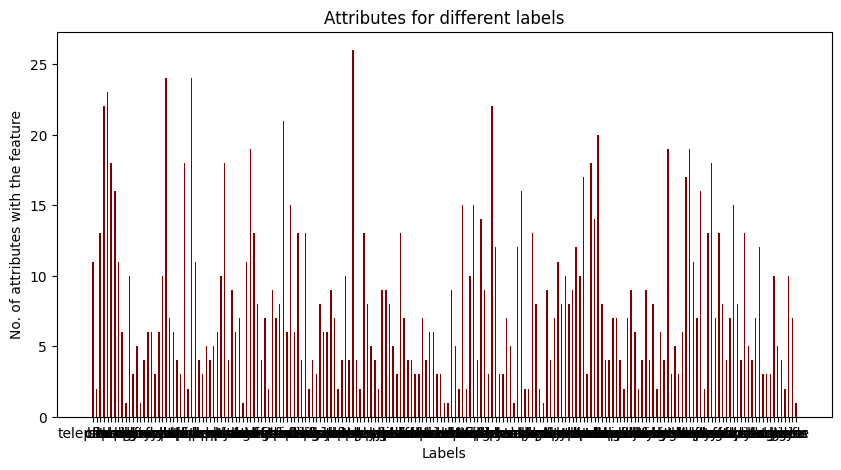

In [96]:
label_list = []
label_set = set()

for i in label:
        label_set.add(i)
        label_list.append(i)

dict = {}
for i in label_set:
    dict[i] = 0

for i in label_list:
    dict[i] = dict[i]+1

print("Labels and their corresponding count:")
print(dict)

# Plotting the bar plot
labels_used = list(dict.keys())
values_used = list(dict.values())
  
fig = plt.figure(figsize = (10, 5))
plt.bar(labels_used, values_used, color ='maroon',width = 0.4)
plt.xlabel("Labels")
plt.ylabel("No. of attributes with the feature")
plt.title("Attributes for different labels")
plt.show()

# KNN Class

In [97]:
class KNN:
    def __init__(self, k, encoder_type, dist_met):
        self.encoder_type = encoder_type
        self.k = k
        self.dist_name = dist_met
        self.distance_metric = self._get_distance_metric()
        
    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((np.square(x1-x2))))
    
    def _manhattan_distance(self, x1, x2):
        return np.sum(np.abs(x1 - x2))

    def _cosine_distance(self, x1, x2):
        return 1-(np.dot(x1,x2)/(np.linalg.norm(x1) * np.linalg.norm(x2)))
    
    def _get_distance_metric(self):
        if self.dist_name == 'euclidean':
            return self._euclidean_distance
        elif self.dist_name == 'manhattan':
            return self._manhattan_distance
        elif self.dist_name == 'cosine':
            return self._cosine_distance
        else:
            raise ValueError("Unsupported encoder type")
            
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    # This function below is inspired from ChatGPT
    def predict(self, X_test):
        y_pred = []
        k_nearest = []
        for x in X_test:
            distance_metric = self._get_distance_metric()
            distances = [self.distance_metric(x, x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            y_pred.append(most_common[0][0])
        return y_pred
    
    def evaluate(self, X_val, y_val):
        y_pred = self.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='weighted')
        accuracy = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=1, average='weighted')
        recall = recall_score(y_val, y_pred, zero_division=1, average='weighted')
        return f1, accuracy, precision, recall
    
    # Another function to verify outputs
    def evaluate2(self, X_val, y_val):
        y_pred = self.predict(X_val)
        correct = np.sum(np.array(y_pred) == np.array(y_val))
        accuracy = correct / len(y_val)
        
        tp = np.sum(np.logical_and(np.array(y_pred) == 1, np.array(y_val) == 1))
        fp = np.sum(np.logical_and(np.array(y_pred) == 1, np.array(y_val) == 0))
        fn = np.sum(np.logical_and(np.array(y_pred) == 0, np.array(y_val) == 1))

        if (tp+fp) == 0: 
            precision = 1 
        else:
            precision = tp / (tp + fp)

        if (tp+fn) == 0: 
            recall = 1 
        else:
            recall = tp / (tp + fn)
            
        f1 = 2 * (precision * recall) / (precision + recall)
        
        return accuracy, precision, recall, f1

X_train_Resnet, X_val_Resnet, y_train_Resnet, y_val_Resnet = train_test_split(Resnet_input, label, test_size=0.2, random_state=42)
X_train_VIT, X_val_VIT, y_train_VIT, y_val_VIT = train_test_split(VIT_input, label, test_size=0.2, random_state=42)


# 2.4 Hyperparameter Tuning

For embedding = Resnet, distance metric = euclidean and k=1, 
 Accuracy = 0.18380278980278983, Precision = 0.18666666666666668, Recall = 0.48909523809523797, F1 Score = 0.18666666666666668

Elapsed time =  5.124028921127319
For embedding = Resnet, distance metric = euclidean and k=2, 
 Accuracy = 0.18380278980278983, Precision = 0.18666666666666668, Recall = 0.48909523809523797, F1 Score = 0.18666666666666668

Elapsed time =  5.191034555435181
For embedding = Resnet, distance metric = euclidean and k=3, 
 Accuracy = 0.19012794612794612, Precision = 0.19666666666666666, Recall = 0.4935793650793651, F1 Score = 0.19666666666666666

Elapsed time =  5.131221532821655
For embedding = Resnet, distance metric = euclidean and k=4, 
 Accuracy = 0.18003604728604727, Precision = 0.19, Recall = 0.4854880952380952, F1 Score = 0.19

Elapsed time =  5.056750774383545
For embedding = Resnet, distance metric = euclidean and k=5, 
 Accuracy = 0.19083554408554407, Precision = 0.20333333333333334, Recall =

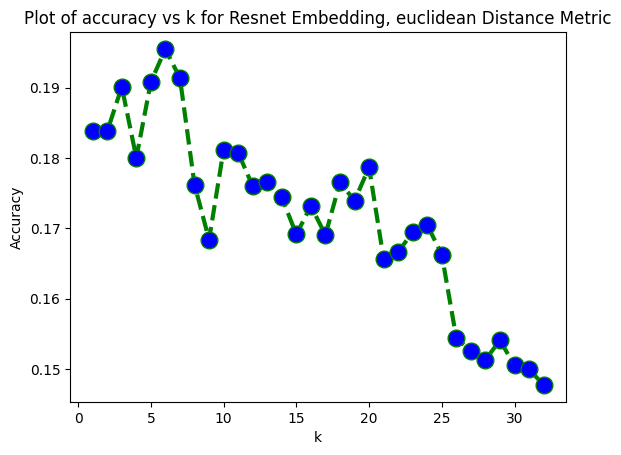

For embedding = Resnet, distance metric = manhattan and k=1, 
 Accuracy = 0.18455206449324096, Precision = 0.18666666666666668, Recall = 0.4685873015873016, F1 Score = 0.18666666666666668

Elapsed time =  4.404692888259888
For embedding = Resnet, distance metric = manhattan and k=2, 
 Accuracy = 0.18455206449324096, Precision = 0.18666666666666668, Recall = 0.4685873015873016, F1 Score = 0.18666666666666668

Elapsed time =  4.394259691238403
For embedding = Resnet, distance metric = manhattan and k=3, 
 Accuracy = 0.18323195867313516, Precision = 0.18666666666666668, Recall = 0.4653280423280423, F1 Score = 0.18666666666666668

Elapsed time =  4.460339069366455
For embedding = Resnet, distance metric = manhattan and k=4, 
 Accuracy = 0.19150877444995093, Precision = 0.2, Recall = 0.47434920634920635, F1 Score = 0.2

Elapsed time =  4.43058705329895
For embedding = Resnet, distance metric = manhattan and k=5, 
 Accuracy = 0.20084504384504387, Precision = 0.21333333333333335, Recall = 0.5

In [98]:
class triplet:
    def __init__(self, a, k, e, dm):
        self.acc = a
        self.k_val = k
        self.enc_type = e
        self.dist_metr = dm
  
  # function for customized printing
    def print_me(self):
        print("Accuracy: {}, k: {}, Embedding: {}, Distance Metric: {}".format \
              (self.acc, self.k_val, self.enc_type, self.dist_metr))
        print('\n')
  
   # override the comparison operator
    def __lt__(self, nxt):
        return self.acc < nxt.acc
        
encoder_vals = ['Resnet', 'VIT']
distance_metric_vals = ['euclidean', 'manhattan', 'cosine']

dist_metric_plot = 'euclidean'
encoder_plot = 'Resnet'

acc_val_plot = []
num_triplets = 20

        
ordered_triplets = []
cnt = 0

for encoding_itr in encoder_vals:
    n = 0
    if encoding_itr == 'Resnet':
        X_train = X_train_Resnet
        X_val = X_val_Resnet
        y_train = y_train_Resnet
        y_val = y_val_Resnet
        n = 1024

    elif encoding_itr == 'VIT':
        X_train = X_train_VIT
        X_val = X_val_VIT
        y_train = y_train_VIT
        y_val = y_val_VIT
        n = 512

    time_list = []
    for dist_metric_itr in distance_metric_vals:
        for k_itr in range(1, round(math.sqrt(n))+1):
            st = time.time()
            knn = KNN(k = k_itr, encoder_type = encoding_itr, dist_met = dist_metric_itr)
            knn.fit(X_train, y_train)
            accuracy, precision, recall, f1 = knn.evaluate(X_val, y_val)   # Check the order  accuracy, recall, f1, precision
            print('For embedding = {}, distance metric = {} and k={}, \n Accuracy = {}, Precision = {}, Recall = {}, F1 Score = {}\n'.format \
                  (encoding_itr, dist_metric_itr, k_itr, accuracy, precision, recall, f1))
            
            if encoding_itr == encoder_plot and dist_metric_itr == dist_metric_plot:
                acc_val_plot.append(accuracy)
                
            if len(ordered_triplets)<num_triplets:
                ordered_triplets.append(triplet(accuracy, k_itr, encoding_itr, dist_metric_itr))
                # print(hq.nsmallest(1, ordered_triplets))
            if len(ordered_triplets)==num_triplets:
                hq.heapify(ordered_triplets)
            if len(ordered_triplets)>=num_triplets and hq.nsmallest(1, ordered_triplets)[0].acc < accuracy:
                hq.heappushpop(ordered_triplets, triplet(accuracy, k_itr, encoding_itr, dist_metric_itr))
            end = time.time()
            print("Elapsed time = ", end-st)
            time_list.append([end-st, k_itr, encoding_itr, dist_metric_itr])
            
        if encoding_itr == encoder_plot and dist_metric_itr == dist_metric_plot:
            plt.plot(list(range(1,round(math.sqrt(n))+1)), acc_val_plot, color='green', linestyle='dashed', linewidth = 3, \
                     marker='o', markerfacecolor='blue', markersize=12)
            plt.xlabel('k')
            plt.ylabel('Accuracy')
            plt.title('Plot of accuracy vs k for {} Embedding, {} Distance Metric'.format(encoder_plot, dist_metric_plot))
            plt.show()
            
items = hq.nlargest(num_triplets, ordered_triplets)
for i in range(0, num_triplets):
    items[i].print_me()

hq.heapify(time_list)
opt = hq.heappop(time_list)
print("Most Time Optimised Hyperparameters: ", opt)
    
# Reference for Heaps: https://www.geeksforgeeks.org/heapq-with-custom-predicate-in-python/


# 2.6 Optimization

## Inference time vs train dataset size for different models

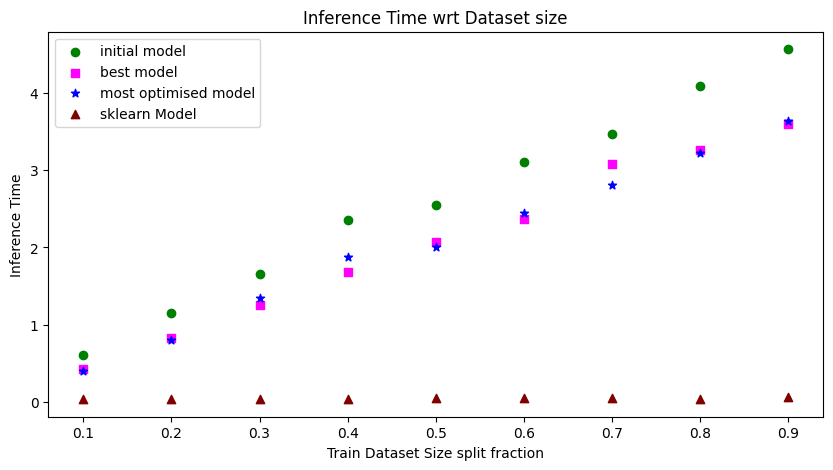

In [99]:
# Initial Model
x_axis = []
y_axis = []

for i in range(1,10):
    st = time.time()
    X_used_VIT, X_rest, y_used_VIT, y_rest = train_test_split(X_train_VIT, y_train_VIT, train_size=i/10, random_state=42)
    knn = KNN(k = 1, encoder_type = 'VIT', dist_met = 'euclidean')
    knn.fit(X_used_VIT, y_used_VIT)
    knn.evaluate(X_val_VIT, y_val_VIT)
    end = time.time()
    y_axis.append(end-st)
    x_axis.append(i/10)

fig = plt.figure(figsize = (10, 5))
plt.scatter(x_axis, y_axis, color ='green')

# Best Model (wrt time)

x_axis = []
y_axis = []
for i in range(1,10):
    st = time.time()
    knn = KNN(k = 6, encoder_type = 'VIT', dist_met = 'manhattan')
    X_used_VIT, X_rest, y_used_VIT, y_rest = train_test_split(X_train_VIT, y_train_VIT, train_size=i/10, random_state=42)
    knn.fit(X_used_VIT, y_used_VIT)
    knn.evaluate(X_val_VIT, y_val_VIT)
    end = time.time()
    y_axis.append(end-st)
    x_axis.append(i/10)

plt.scatter(x_axis, y_axis, color ='magenta',marker ="s")

# Most Optimised Model (wrt Accuracy)

x_axis = []
y_axis = []
for i in range(1,10):
    st = time.time()
    knn = KNN(k = 13, encoder_type = 'VIT', dist_met = 'manhattan')
    X_used_VIT, X_rest, y_used_VIT, y_rest = train_test_split(X_train_VIT, y_train_VIT, train_size=i/10, random_state=42)
    knn.fit(X_used_VIT, y_used_VIT)
    knn.evaluate(X_val_VIT, y_val_VIT)
    end = time.time()
    y_axis.append(end-st)
    x_axis.append(i/10)

plt.scatter(x_axis, y_axis, color ='blue',marker ="*")

# sklearn Model - Trained for VIT Dataset with k=7

x_axis = []
y_axis = []
for i in range(1,10):
    st = time.time()
    knn_def = KNeighborsClassifier(n_neighbors=7)
    X_used_VIT, X_rest, y_used_VIT, y_rest = train_test_split(X_train_VIT, y_train_VIT, train_size=i/10, random_state=11)
    knn_def.fit(X_used_VIT, y_used_VIT)
    knn_def.score(X_val_VIT, y_val_VIT)
    end = time.time()
    y_axis.append(end-st)
    x_axis.append(i/10)

plt.scatter(x_axis, y_axis, color ='maroon', marker ="^")
plt.xlabel("Train Dataset Size split fraction")
plt.ylabel("Inference Time")
plt.title("Inference Time wrt Dataset size")
plt.plot()
plt.legend(["initial model", "best model", "most optimised model", "sklearn Model"])
plt.show()


## Plotting inference time with models

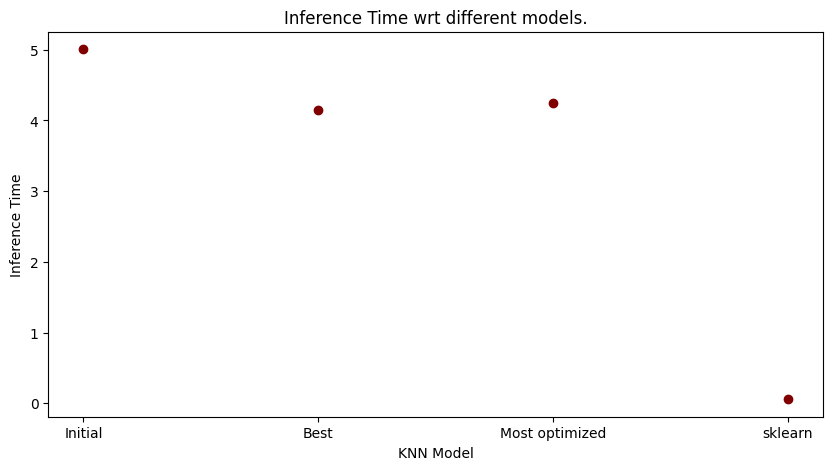

In [100]:
# Training model using sklearn 
# Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

y_axis_model = []

# Initial Model 
st = time.time()
knn = KNN(k = 1, encoder_type = 'VIT', dist_met = 'euclidean')
knn.fit(X_train_VIT, y_train_VIT)
knn.evaluate(X_val_VIT, y_val_VIT)
end = time.time()
y_axis_model.append(end-st)

# Best Model (wrt time): k: 13, Embedding: VIT, Distance Metric: manhattan
st = time.time()
knn = KNN(k = 6, encoder_type = 'VIT', dist_met = 'manhattan')
knn.fit(X_train_VIT, y_train_VIT)
knn.evaluate(X_val_VIT, y_val_VIT)
end = time.time()
y_axis_model.append(end-st)

# Most Optimised Model (wrt Accuracy)
st = time.time()
knn = KNN(k = 13, encoder_type = 'VIT', dist_met = 'manhattan')
knn.fit(X_train_VIT, y_train_VIT)
knn.evaluate(X_val_VIT, y_val_VIT)
end = time.time()
y_axis_model.append(end-st)

# sklearn Model - Trained for VIT dataset with k = 7
from sklearn.neighbors import KNeighborsClassifier
st = time.time()
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_VIT, y_train_VIT)
knn.score(X_val_VIT, y_val_VIT)
end = time.time()
y_axis_model.append(end-st)

x_axis = ['Initial', 'Best', 'Most optimized', 'sklearn']

fig = plt.figure(figsize = (10, 5))
plt.scatter(x_axis, y_axis_model, color ='maroon')
plt.xlabel("KNN Model")
plt.ylabel("Inference Time")
plt.title("Inference Time wrt different models.")
plt.show()


# 3. Decision Trees

# Data Exploration and Visualisation

In [101]:
# Importing required libraries.

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import math
import heapq as hq

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, multilabel_confusion_matrix
from sklearn.model_selection import KFold 


Labels and their corresponding count:
{'home': 340, 'electronics': 332, 'furniture': 336, 'beauty': 356, 'clothing': 334, 'books': 355, 'food': 343, 'sports': 362}


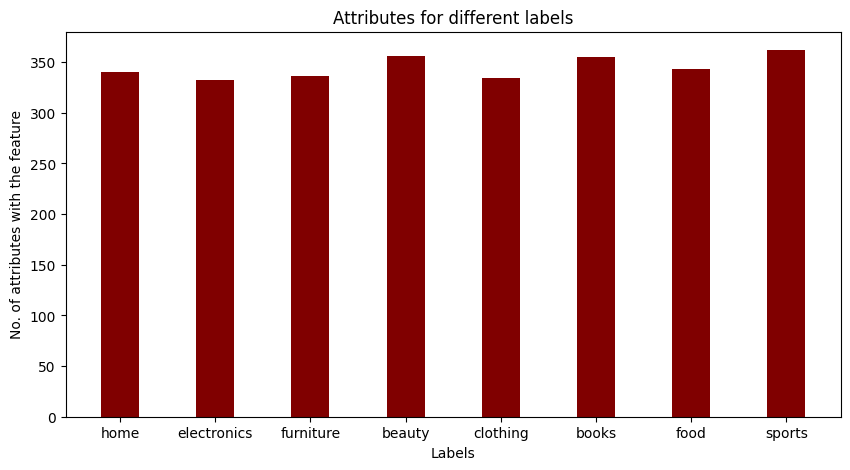

In [102]:

df = pd.read_csv('advertisement.csv')

# Documentation links referred.
# https://pandas.pydata.org/docs/getting_started/intro_tutorials/04_plotting.html

label = list(df['labels'])
label_list = []
label_set = set()

for i in label:
    lis_dum = i.split()
    for j in lis_dum:
        label_set.add(j)
        label_list.append(j)

dict = {}
for i in label_set:
    dict[i] = 0

for i in label_list:
    dict[i] = dict[i]+1

print("Labels and their corresponding count:")
print(dict)

# Plotting the bar plot
labels_used = list(dict.keys())
values_used = list(dict.values())
  
fig = plt.figure(figsize = (10, 5))
plt.bar(labels_used, values_used, color ='maroon',width = 0.4)
plt.xlabel("Labels")
plt.ylabel("No. of attributes with the feature")
plt.title("Attributes for different labels")
plt.show()
    

# Data preprocessing

In [103]:
print(df.city.unique().shape)
df.drop(columns=['city'], inplace=True)
df

(969,)


,age,gender,income,education,married,children,occupation,purchase_amount,most bought item,labels
0,45,Male,61271.953359,Master,False,3,Doctor,87.697118,monitor,electronics clothing sports
1,24,Female,53229.101074,High School,False,1,Businessman,115.135586,lipstick,furniture beauty
2,45,Female,30066.046684,Bachelor,True,3,Engineer,101.694559,biscuits,clothing electronics food sports
3,19,Male,48950.246384,PhD,False,0,Lawyer,97.964887,maggi,food
4,29,Female,44792.627094,Master,False,0,Businessman,86.847281,carpet,home
...,...,...,...,...,...,...,...,...,...,...
995,61,Male,34246.773063,Master,True,3,HR,103.357441,bed,food furniture
996,56,Female,45494.225591,Bachelor,False,0,Engineer,85.159023,biscuits,home clothing food
997,64,Female,68740.442006,PhD,True,0,Salesman,101.434650,bat,sports clothing
998,18,Female,44348.446680,Bachelor,True,0,Retired,97.649988,perfume,beauty


# Data Featurization

In [104]:

# Encoding binary values for features
df.replace([False, True], [0,1], inplace=True)
df.replace(['Male', 'Female'], [0,1], inplace=True)


In [105]:
print(df.education.unique())
df['education'].replace(['High School','Bachelor', 'Master', 'PhD'], [1,2,3,4], inplace=True)

['Master' 'High School' 'Bachelor' 'PhD']


In [106]:
# One-hot encoding for columns with less unique values
print(df['most bought item'].unique())
print(df['occupation'].unique())
df = pd.get_dummies(df, columns=['most bought item', 'occupation'], dtype=int)
df

['monitor' 'lipstick' 'biscuits' 'maggi' 'carpet' 'laptop' 'table'
 'dictionary' 'curtains' 'chips' 'shoes' 'bat' 'gloves' 'pants' 'novel'
 'bed' 'mobile' 'cream' 'encyclopedia' 'chair' 'shirt' 'sofa' 'ball'
 'perfume']
['Doctor' 'Businessman' 'Engineer' 'Lawyer' 'Scientist' 'Housewife'
 'Salesman' 'Artist' 'HR' 'Unemployed' 'Retired']


,age,gender,income,education,married,children,purchase_amount,labels,most bought item_ball,most bought item_bat,...,occupation_Businessman,occupation_Doctor,occupation_Engineer,occupation_HR,occupation_Housewife,occupation_Lawyer,occupation_Retired,occupation_Salesman,occupation_Scientist,occupation_Unemployed
0,45,0,61271.953359,3,0,3,87.697118,electronics clothing sports,0,0,...,0,1,0,0,0,0,0,0,0,0
1,24,1,53229.101074,1,0,1,115.135586,furniture beauty,0,0,...,1,0,0,0,0,0,0,0,0,0
2,45,1,30066.046684,2,1,3,101.694559,clothing electronics food sports,0,0,...,0,0,1,0,0,0,0,0,0,0
3,19,0,48950.246384,4,0,0,97.964887,food,0,0,...,0,0,0,0,0,1,0,0,0,0
4,29,1,44792.627094,3,0,0,86.847281,home,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,61,0,34246.773063,3,1,3,103.357441,food furniture,0,0,...,0,0,0,1,0,0,0,0,0,0
996,56,1,45494.225591,2,0,0,85.159023,home clothing food,0,0,...,0,0,1,0,0,0,0,0,0,0
997,64,1,68740.442006,4,1,0,101.434650,sports clothing,0,1,...,0,0,0,0,0,0,0,1,0,0
998,18,1,44348.446680,2,1,0,97.649988,beauty,0,0,...,0,0,0,0,0,0,1,0,0,0


# Powerset Formulation

In [107]:

class PowersetDecisionTreeClassifier:
    def __init__(self, max_depth=30, max_features=11, criterion='gini'):
        self.model = None
        self.max_depth = max_depth
        self.max_features = max_features
        self.criterion = criterion
        
    def PowerSet(self, label):
        powerset_size = (int) (math.pow(2, len(label)))
        powerset = []
        for counter in range(0, powerset_size):
            lists = []
            for i in range(0, len(label)):
                if (counter & (1 << i)) > 0:
                    lists.append(label[i])
            powerset.append(lists)
        return powerset 
        
    def fit(self,X,y):
        self.model = DecisionTreeClassifier(max_depth=self.max_depth, \
                     max_features=self.max_features, criterion=self.criterion)
        self.model.fit(X, y)
        
    def predict(self,X):
        return self.model.predict(X)

    # Another function to verify outputs
    def evaluate2(self, X_val, y_val):
        y_pred = self.model.predict(X_val)
        correct = np.sum(np.array(y_pred) == np.array(y_val))
        accuracy = correct / len(y_val)
        tp = np.sum(np.logical_and(np.array(y_pred) == 1, np.array(y_val) == 1))
        fp = np.sum(np.logical_and(np.array(y_pred) == 1, np.array(y_val) == 0))
        fn = np.sum(np.logical_and(np.array(y_pred) == 0, np.array(y_val) == 1))
        
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        f1 = 2 * (precision * recall) / (precision + recall)
        
        return f1, accuracy, precision, recall

    def evaluate(self, X_val, y_val):
        y_pred = self.model.predict(X_val)
        confusion_matrix = multilabel_confusion_matrix(y_pred, y_val)
        f1_micro = f1_score(y_val, y_pred, zero_division=1, average='micro')
        f1_macro = f1_score(y_val, y_pred, zero_division=1, average='macro')
        accuracy = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=1, average='weighted')
        recall = recall_score(y_val, y_pred, zero_division=1, average='weighted')
        return f1_micro, f1_macro, accuracy, precision, recall, confusion_matrix
        

In [108]:
# Creating powerset of labels
labels = list(label_set)
powerset = PowersetDecisionTreeClassifier().PowerSet(labels)
powerset = [sorted(t) for t in powerset]
# print(powerset)

In [109]:
# ChatGPT inspired cell
label_one_hot = pd.DataFrame(columns = [f'{i}' for i in powerset])
df['split_labels'] = df['labels'].str.split()
for i in df['split_labels']:
    label_one_hot.loc[len(label_one_hot.index)] = [1 if j == powerset.index(sorted(i)) else 0 for j in range(256)]

In [110]:
# Train-Val-Test split
X = df.drop(columns=['labels', 'split_labels'])
X_train, X_temp, y_train, y_temp = train_test_split(X, label_one_hot, test_size=0.2, random_state=11)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.25, random_state=11)

# Model Training and Evalation
criterion = ['gini', 'entropy']
max_depth = [3,5,10,20,30]
max_features = [3,5,7,9,11]

num_triplets=3
top_hyperpara = []
time_opt = []
for crt in criterion:
    for depth in max_depth:
        for feat in max_features:
            st = time.time()
            powerset_tree = PowersetDecisionTreeClassifier(max_depth=depth, max_features=feat, criterion=crt)
            powerset_tree.fit(X_train, y_train)
            f1_micro, f1_macro, acc, prec, recall, conf_mtr= powerset_tree.evaluate(X_val, y_val)
            print("For Criterion = {}, Max Depth = {}, Max Features = {}, \n F1 Micro = {}, F1 Macro = {}, Accuracy = {}, Precision = {}, Recall = {}" \
            .format(crt, depth, feat, f1_micro, f1_macro, acc, prec, recall))
            print(conf_mtr)
            top_hyperpara.append([f1_macro, crt, depth, feat])
            end = time.time()
            print("Elapsed Time = ", end-st)
            time_opt.append([end-st, crt, depth, feat])
            
print("\n\n")
hq.heapify(top_hyperpara)
items = hq.nlargest(num_triplets, top_hyperpara)
for i in items:
    print("For Criterion = {}, Max Depth = {}, Max Features = {}, F1 Score = {}".format(i[1], i[2], i[3], i[0]))

hq.heapify(time_opt)
mm = hq.heappop(time_opt)
print("Most Time Optimised Hyperparameters: ", mm[1:])

For Criterion = gini, Max Depth = 3, Max Features = 3, 
 F1 Micro = 0.0, F1 Macro = 0.62890625, Accuracy = 0.0, Precision = 1.0, Recall = 0.0
[[[150   0]
  [  0   0]]

 [[148   2]
  [  0   0]]

 [[147   3]
  [  0   0]]

 ...

 [[150   0]
  [  0   0]]

 [[150   0]
  [  0   0]]

 [[150   0]
  [  0   0]]]
Elapsed Time =  0.13640213012695312
For Criterion = gini, Max Depth = 3, Max Features = 5, 
 F1 Micro = 1.0, F1 Macro = 0.63671875, Accuracy = 0.0, Precision = 0.9733333333333334, Recall = 0.0
[[[150   0]
  [  0   0]]

 [[148   2]
  [  0   0]]

 [[147   3]
  [  0   0]]

 ...

 [[150   0]
  [  0   0]]

 [[150   0]
  [  0   0]]

 [[150   0]
  [  0   0]]]
Elapsed Time =  0.19041943550109863
For Criterion = gini, Max Depth = 3, Max Features = 7, 
 F1 Micro = 1.0, F1 Macro = 0.6328125, Accuracy = 0.0, Precision = 0.98, Recall = 0.0
[[[150   0]
  [  0   0]]

 [[148   2]
  [  0   0]]

 [[147   3]
  [  0   0]]

 ...

 [[150   0]
  [  0   0]]

 [[150   0]
  [  0   0]]

 [[150   0]
  [  0   0]]]
E

## K fold Cross Validation


In [111]:
# Best Model: For Criterion = entropy, Max Depth = 30, Max Features = 9, F1 Score = 0.5755555555555555

k = 5
kf = KFold(n_splits=k, random_state=None)

powerset_tree = PowersetDecisionTreeClassifier(max_depth=30, max_features=9, criterion='entropy')
 
acc_score = []
 
for train_index , test_index in kf.split(X):
    powerset_tree.fit(X_train, y_train)
    pred_values = powerset_tree.predict(X_val)
     
    acc = accuracy_score(pred_values , y_val)
    acc_score.append(acc)
     
avg_acc_score = sum(acc_score)/k
 
print('accuracy of each fold - {}'.format(acc_score))
print('Avg accuracy : {}'.format(avg_acc_score))


accuracy of each fold - [0.013333333333333334, 0.006666666666666667, 0.006666666666666667, 0.013333333333333334, 0.02]
Avg accuracy : 0.012


# MultiOutput Formulation

In [112]:
labels_all = []

mlb = MultiLabelBinarizer()

for elems in df['labels']:
    temp = elems.split(' ')
    labels_all.append(temp)

y_multi_op = mlb.fit_transform(labels_all)


In [113]:
# Train-Val-Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y_multi_op, test_size=0.2, random_state=11)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.25, random_state=11)

# Model Training and Evalation
criterion = ['gini', 'entropy']
max_depth = [3,5,10,20,30]
max_features = [3,5,7,9,11]

num_triplets=3
top_hyperpara = []
time_opt = []
for crt in criterion:
    for depth in max_depth:
        for feat in max_features:
            start = time.time()
            powerset_tree = PowersetDecisionTreeClassifier(max_depth=depth, max_features=feat, criterion=crt)
            powerset_tree.fit(X_train, y_train)
            f1_micro, f1_macro, acc, prec, recall, cnf_mat = powerset_tree.evaluate(X_val, y_val)
            print("For Criterion = {}, Max Depth = {}, Max Features = {}, \n F1 Micro = {}, F1 Macro = {}, Accuracy = {}, Precision = {}, Recall = {}" \
            .format(crt, depth, feat, f1_micro, f1_macro, acc, prec, recall))
            print(cnf_mat)
            top_hyperpara.append([f1, crt, depth, feat])
            end = time.time()
            print("Elapsed Time = ", end-start)
            time_opt.append([end-st, crt, depth, feat])
print("\n\n")
hq.heapify(top_hyperpara)
items = hq.nlargest(num_triplets, top_hyperpara)
for i in items:
    print("For Criterion = {}, Max Depth = {}, Max Features = {}, F1 Score = {}".format(i[1], i[2], i[3], i[0]))

hq.heapify(time_opt)
mm = hq.heappop(time_opt)
print("Most Time Optimised Hyperparameters: ", mm[1:])

For Criterion = gini, Max Depth = 3, Max Features = 3, 
 F1 Micro = 0.037914691943127965, F1 Macro = 0.15938228438228436, Accuracy = 0.02666666666666667, Precision = 0.8813559322033898, Recall = 0.01937046004842615
[[[102  44]
  [  0   4]]

 [[100  49]
  [  1   0]]

 [[ 94  56]
  [  0   0]]

 [[102  48]
  [  0   0]]

 [[101  49]
  [  0   0]]

 [[ 99  51]
  [  0   0]]

 [[100  50]
  [  0   0]]

 [[ 88  58]
  [  0   4]]]
Elapsed Time =  0.02510356903076172
For Criterion = gini, Max Depth = 3, Max Features = 5, 
 F1 Micro = 0.07441860465116279, F1 Macro = 0.18690200210748154, Accuracy = 0.03333333333333333, Precision = 0.8837772397094431, Recall = 0.0387409200968523
[[[102  44]
  [  0   4]]

 [[101  49]
  [  0   0]]

 [[ 94  56]
  [  0   0]]

 [[101  48]
  [  1   0]]

 [[101  48]
  [  0   1]]

 [[ 99  51]
  [  0   0]]

 [[100  50]
  [  0   0]]

 [[ 88  51]
  [  0  11]]]
Elapsed Time =  0.024619340896606445
For Criterion = gini, Max Depth = 3, Max Features = 7, 
 F1 Micro = 0.0835266821345

In [114]:
# Best Model: Criterion = entropy, Max Depth = 20, Max Features = 11, F1 Score = 0.5169797074668342

k = 5
kf = KFold(n_splits=k, random_state=None)

powerset_tree = PowersetDecisionTreeClassifier(max_depth=20, max_features=11, criterion='entropy')
 
acc_score = []
 
for train_index , test_index in kf.split(X):
    powerset_tree.fit(X_train, y_train)
    pred_values = powerset_tree.predict(X_val)
     
    acc = accuracy_score(pred_values , y_val)
    acc_score.append(acc)
     
avg_acc_score = sum(acc_score)/k
 
print('accuracy of each fold - {}'.format(acc_score))
print('Avg accuracy : {}'.format(avg_acc_score))


accuracy of each fold - [0.04, 0.09333333333333334, 0.03333333333333333, 0.08, 0.06666666666666667]
Avg accuracy : 0.06266666666666666
